In [6]:
import torch
from NeuralDecoder import MnistNeuralDecoder , CortexMnistDataset
import torch
from torch.utils.data import DataLoader , Dataset
from torch import nn
import torch.nn.functional as F
from ConvLSTM import ConvLSTM
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import copy


In [7]:
train_dataset = CortexMnistDataset('cortex_mnist/train.pt')
val_dataset   = CortexMnistDataset('cortex_mnist/val.pt')
test_dataset  = CortexMnistDataset('cortex_mnist/test.pt')
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=10, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=10, shuffle=False, num_workers=0)
device=torch.device('mps')


In [8]:
spikes_on,_,images=next(iter(test_loader))
best_model=MnistNeuralDecoder(grid_size=40)
best_model_state = torch.load('/Users/mohamed/Cortex-Image-Reconstruction/NeuralDecoder.pth')  # or wherever you saved it
best_model.load_state_dict(best_model_state)
idx=6
spike=spikes_on[6]
spike=spike.float()
img=images[6]
best_model.eval()
with torch.no_grad():
    constructed=best_model(spike.unsqueeze(0))
print(constructed.shape)


(11, 11)
torch.Size([1, 1, 28, 28])


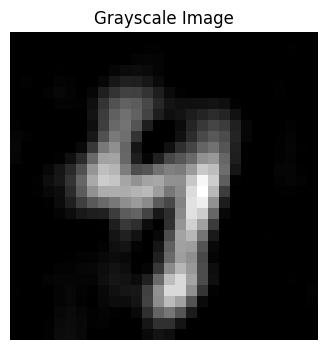

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Assuming your tensor is named 'image_tensor'
# image_tensor = torch.Size([1, 1, 28, 28])
spikes_on,_,images=next(iter(test_loader))
best_model=MnistNeuralDecoder(grid_size=40)
best_model_state = torch.load('/Users/mohamed/Cortex-Image-Reconstruction/NeuralDecoder.pth')  # or wherever you saved it
best_model.load_state_dict(best_model_state)
idx=6
spike=spikes_on[6]
spike=spike.float()
img=images[6]
best_model.eval()
with torch.no_grad():
    constructed=best_model(spike.unsqueeze(0))
print(constructed.shape)

def plot_grayscale_tensor(image_tensor,threshold=0.0):
    # Remove batch and channel dimensions: [1, 1, 28, 28] -> [28, 28]
    image = image_tensor.squeeze().numpy()
    image=np.where(image<threshold,0,image)
    # Create the plot
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap='gray')
    plt.axis('off')  # Turn off axes
    plt.title('Grayscale Image')
    plt.show()

# Example usage:
plot_grayscale_tensor(constructed)
plot_grayscale_tensor(img)


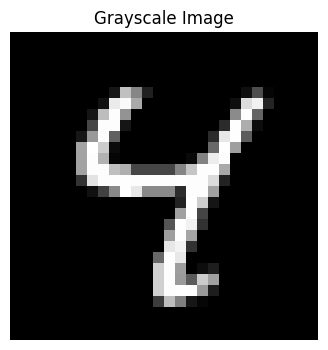

In [10]:
plot_grayscale_tensor(img)